# Diabetes Prediction: From Raw Data to Evaluation

**Task:** Binary Classification — determine whether a patient is diabetic (`1`) or non-diabetic (`0`).

**Workflow:**

```text
0. Set up the environment and import the dataset
1. Explore and understand the dataset and its features
2. Perform EDA: analyze individual features, then relationships between features
3. Handle missing values using imputation
4. Clean the data by removing duplicates and fixing inconsistent text
5. Convert categorical/text features into numerical values
6. Examine feature relationships using a correlation matrix
7. Split the data into training and testing sets, then standardize the features
8. Train XGBoost and LightGBM models
9. Exercise: calculate the evaluation metrics manually
10. Review the confusion matrix and overall evaluation metrics
11. Use SHAP to understand the reasons behind the model's predictions
```


In [4]:
!pip install catboost
!pip install xgboost lightgbm shap -q
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
from sklearn.metrics import roc_auc_score , average_precision_score , confusion_matrix
from sklearn.metrics import RocCurveDisplay , PrecisionRecallDisplay


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale = 1.1)
COLORS ={0:"#4C72B0" , 1:"#DD8452"}
LABELS ={0:"No diabets" , 1:"Diabetes"}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00


##Data creation


In [5]:
rng = np.random.default_rng(7)
n=1500


age=rng.integers(20 , 80 ,n )
bmi = rng.normal(28 , 6 ,n ).clip(16,50)
glucose = 85 + 0.8 * (bmi -28) + 0.3 * (age -45) + rng.normal(15 , 22 ,n )
glucose - np.where(glucose < 65, rng.uniform(65,80,n), glucose).clip(max=220)
bp=75+0.4*(bmi-28)+rng.normal(0,9,n)
activity = rng.choice( ["Low" , "Medium" , "High"] , n  , p=[0.4 , 0.35 , 0.25])
smoking=rng.choice(["Never" , "Former" , "Current"] , n , p=[0.55 , 0.25 , 0.20])
family=rng.choice(["Yes " , "No"] , n , p=[0.3 , 0.7])
gender = rng.choice(["Male" , "Female"] , n)


logit = (-1.2 + 0.05 *(glucose -105) + 1.3 * (glucose>=126) + 0.07 *(bmi -28)
          + 0.03 * (age-45) + 1.0 *(family=="Yes")+0.015 * (bp-75)
          +0.6 * (smoking=="Current") +0.25 * (smoking == "High")
          -0.6 * (activity =="Medium") - 1.3 * (activity == "High"))
diabetes = rng.binomial(1 , 1/(1+np.exp(-logit)))


#how hospital system acctually record things
gender = np.where(rng.random(n) < 0.12 , rng.choice(["male" , "M", "female" ,"F"] , n) , gender)
glucose =np.where(rng.random(n) < 0.02 , 0 , glucose.round() )
bp= np.where(rng.random(n) < 0.03 , 0 , bp.round())
insulin = np.where(rng.random(n) < 0.09 ,np.nan , (100 + 3 * (bmi-28) + rng.normal(0 , 35 , n )).clip(15 , 350).round())
bmi= np.where(rng.random(n) < 0.03 ,np.nan  , bmi.round(1))
smoking = np.where(rng.random(n) < 0.04 , None , smoking )

raw=pd.DataFrame({ "PatientID":np.arange(1001 , 1001 +n), "Age":age , "Gender": gender , "BMI": bmi ,
                  "Glucose": glucose, "BloodPressure":bp , "Insulin": insulin , "FamilyHistory": family,
                   "SmokingStatus":smoking , "ActivityLevel":activity , "Diabetes":diabetes})

raw= pd.concat([raw , raw.sample(45 , random_state=3)]).sample(frac=1 , random_state=4)
raw.to_csv("diabetes_raw.csv" , index=False)
print ("Saved to diabetes_raw.csv")



Saved to diabetes_raw.csv


In [6]:
df = pd.read_csv("diabetes_raw.csv")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head(10)

Rows: 1545
Columns: 11


,PatientID,Age,Gender,BMI,Glucose,BloodPressure,Insulin,FamilyHistory,SmokingStatus,ActivityLevel,Diabetes
0,1189,48,Male,28.4,86.0,61.0,94.0,No,Never,Low,0
1,2342,50,Male,19.9,106.0,69.0,99.0,Yes,Current,Medium,1
2,1727,69,Female,28.6,153.0,60.0,121.0,No,Never,Medium,1
3,1794,65,Female,27.5,105.0,66.0,137.0,No,Current,High,0
4,1550,42,Female,36.4,123.0,95.0,165.0,No,Never,High,0
5,1032,53,Male,29.6,118.0,76.0,127.0,No,Former,Low,1
6,2012,47,Female,23.8,107.0,65.0,48.0,No,Former,Low,1
7,1439,69,Male,26.5,99.0,71.0,106.0,Yes,NaN,Medium,1
8,2320,24,Male,36.7,79.0,85.0,NaN,Yes,NaN,Low,0
9,2324,36,Female,26.5,68.0,55.0,108.0,No,Current,Low,0


##1. Understand the Data


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1545 entries, 0 to 1544
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      1545 non-null   int64  
 1   Age            1545 non-null   int64  
 2   Gender         1545 non-null   object 
 3   BMI            1499 non-null   float64
 4   Glucose        1545 non-null   float64
 5   BloodPressure  1545 non-null   float64
 6   Insulin        1406 non-null   float64
 7   FamilyHistory  1545 non-null   object 
 8   SmokingStatus  1491 non-null   object 
 9   ActivityLevel  1545 non-null   object 
 10  Diabetes       1545 non-null   int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 132.9+ KB


Observation: There are four categorical (object) columns that need to be converted into numerical format: Gender, FamilyHistory, SmokingStatus, and ActivityLevel.

FamilyHistory and Gender contain binary categories, so they can be encoded as 0 and 1.
SmokingStatus and ActivityLevel contain three categories , so we can use one-hot encoding to convert them into numerical features.

In [8]:
df.describe().round(1)

,PatientID,Age,BMI,Glucose,BloodPressure,Insulin,Diabetes
count,1545.0,1545.0,1499.0,1545.0,1545.0,1406.0,1545.0
mean,1748.5,49.8,28.0,100.0,72.7,101.0,0.3
std,433.1,17.3,6.0,26.2,15.4,39.1,0.4
min,1001.0,20.0,16.0,0.0,0.0,15.0,0.0
25%,1373.0,35.0,23.7,85.0,68.0,75.0,0.0
50%,1747.0,50.0,27.7,101.0,75.0,101.0,0.0
75%,2124.0,65.0,32.1,116.0,81.0,127.0,1.0
max,2500.0,79.0,45.9,183.0,107.0,219.0,1.0


Glucose and BloodPressure have values of 0, which is clearly wrong because no one can have zero blood pressure or glucose.

Age and BMI seem to have a good range, and their standard deviation is not too high.

PatientID has a high standard deviation, but this is normal because it is just an ID and there is no real relationship between the ID values.

In [9]:
print("Missing values per column")
print(df.isnull().sum())
print()
print("Duplicarted row:", df.duplicated().sum())

Missing values per column
PatientID          0
Age                0
Gender             0
BMI               46
Glucose            0
BloodPressure      0
Insulin          139
FamilyHistory      0
SmokingStatus     54
ActivityLevel      0
Diabetes           0
dtype: int64

Duplicarted row: 45


missing values are in the insulin , BMI and smoking

Univariate: the target (Diabetes)

Question : how many patients have diabetes? Are the classes balensed?

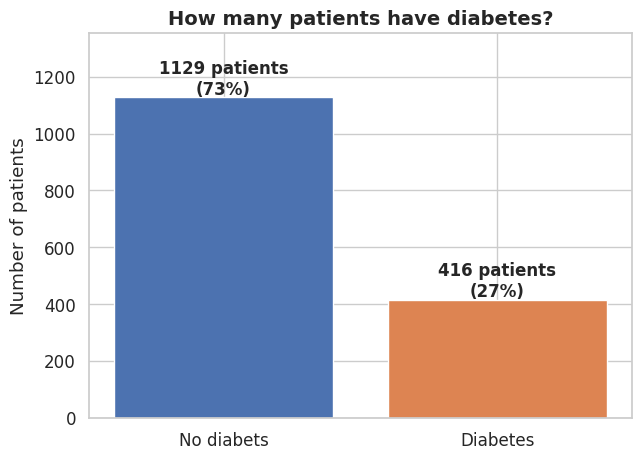

In [10]:
counts = df["Diabetes"].value_counts().sort_index()
percent = counts / counts.sum() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar([LABELS[0], LABELS[1]], counts, color=[COLORS[0], COLORS[1]])

for bar, c, p in zip(bars, counts, percent):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             f"{c} patients\n({p:.0f}%)", ha="center", fontsize=12, fontweight="bold")

plt.title("How many patients have diabetes?", fontsize=14, fontweight="bold")
plt.ylabel("Number of patients")
plt.ylim(0, counts.max() * 1.2)
plt.show()

data are clearliy unbalansed


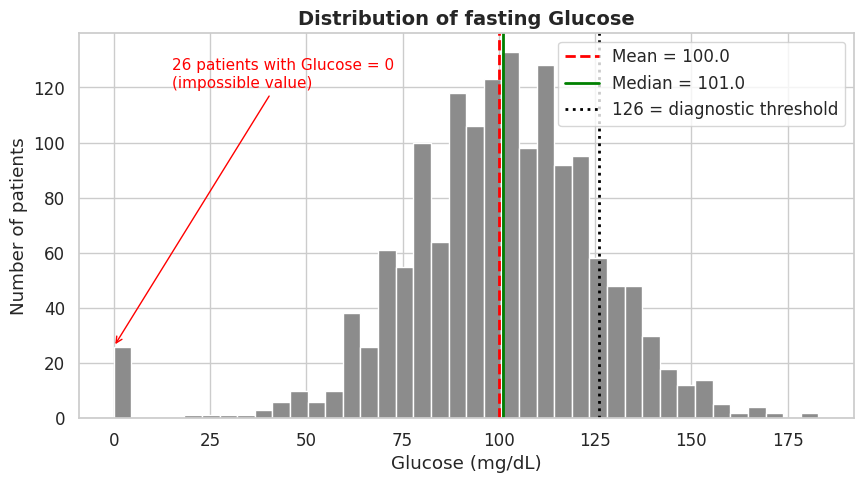

In [11]:
glucose = df["Glucose"]

plt.figure(figsize=(10, 5))
plt.hist(glucose, bins=40, color="#8C8C8C", edgecolor="white")

plt.axvline(glucose.mean(), color="red", linestyle="--", linewidth=2,
            label=f"Mean = {glucose.mean():.1f}")
plt.axvline(glucose.median(), color="green", linestyle="-", linewidth=2,
            label=f"Median = {glucose.median():.1f}")
plt.axvline(126, color="black", linestyle=":", linewidth=2,
            label="126 = diagnostic threshold")

zeros = (glucose == 0).sum()
plt.annotate(f"{zeros} patients with Glucose = 0\n(impossible value)",
             xy=(0, zeros), xytext=(15, 120),
             arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=11)

plt.title("Distribution of fasting Glucose", fontsize=14, fontweight="bold")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Number of patients")
plt.legend()
plt.show()

The graph shows the distribution of glucose values, the mean, and the number of patients who have a glucose value of 0, which is 26.

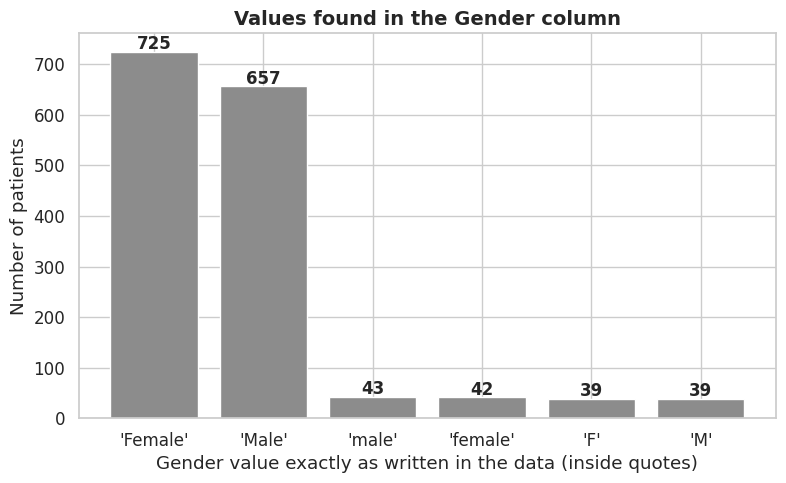

In [12]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar([f"'{v}'" for v in gender_counts.index], gender_counts.values, color="#8C8C8C")

for bar, c in zip(bars, gender_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(c),
             ha="center", fontsize=12, fontweight="bold")

plt.title("Values found in the Gender column", fontsize=14, fontweight="bold")
plt.xlabel("Gender value exactly as written in the data (inside quotes)")
plt.ylabel("Number of patients")
plt.show()

There are multiple values that represent the same gender. For example, "Female", "female", and "F" all mean the same thing, so we should group them into one value and use "Female" to represent them. The same should be done for "Male", "male", and "M".

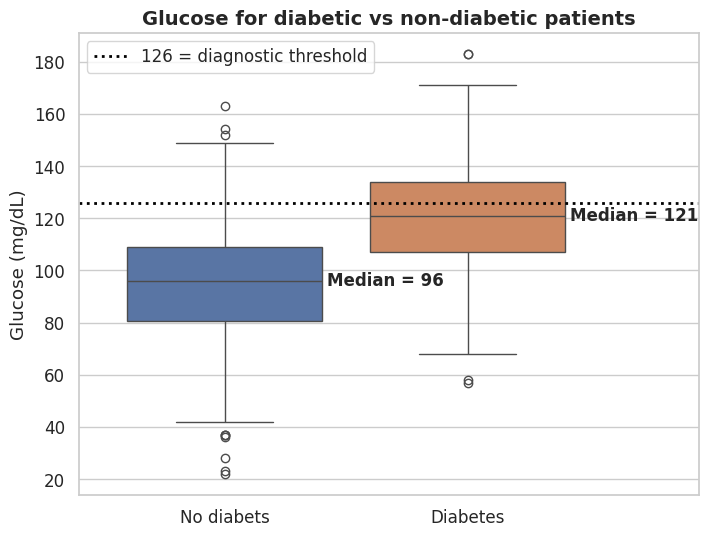

In [13]:
valid = df[df["Glucose"] > 0]

plt.figure(figsize=(8, 6))
sns.boxplot(data=valid, x="Diabetes", y="Glucose", hue="Diabetes", palette=COLORS, legend=False)

for group in [0, 1]:
    median = valid.loc[valid["Diabetes"] == group, "Glucose"].median()
    plt.text(group + 0.42, median, f"Median = {median:.0f}",
             ha="left", va="center", fontsize=12, fontweight="bold")

plt.axhline(126, color="black", linestyle=":", linewidth=2, label="126 = diagnostic threshold")
plt.xticks([0, 1], [LABELS[0], LABELS[1]])
plt.xlim(-0.6, 1.95)
plt.title("Glucose for diabetic vs non-diabetic patients", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Glucose (mg/dL)")
plt.legend(loc="upper left")
plt.show()

an overlap area is where the model will get confuse and may mistake

the small circles are outlier


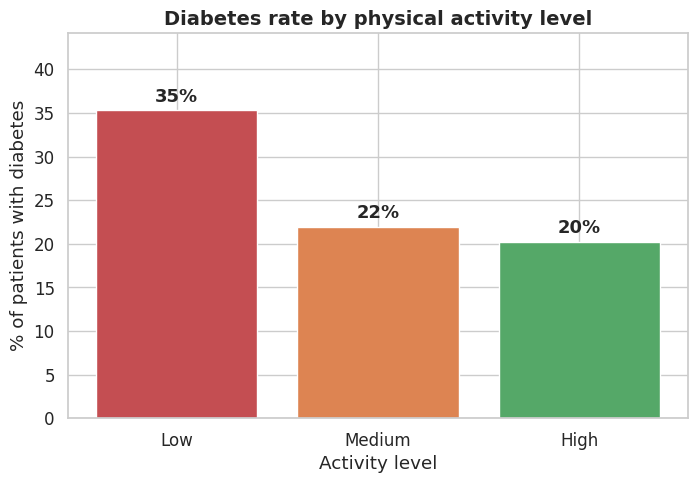

In [14]:
rate = df.groupby("ActivityLevel")["Diabetes"].mean() * 100
rate = rate.reindex(["Low", "Medium", "High"])

plt.figure(figsize=(8, 5))
bars = plt.bar(rate.index, rate.values, color=["#C44E52", "#DD8452", "#55A868"])

for bar, r in zip(bars, rate.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{r:.0f}%",
             ha="center", fontsize=13, fontweight="bold")

plt.title("Diabetes rate by physical activity level", fontsize=14, fontweight="bold")
plt.xlabel("Activity level")
plt.ylabel("% of patients with diabetes")
plt.ylim(0, rate.max() * 1.25)
plt.show()

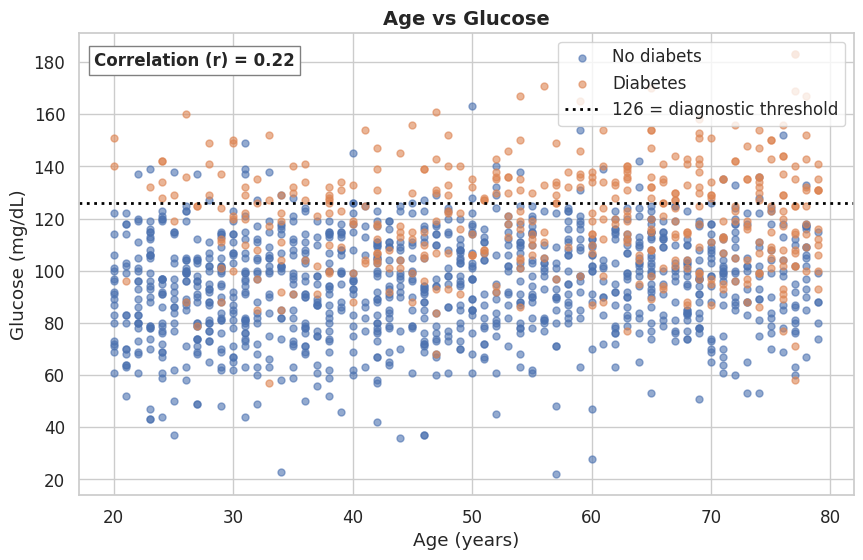

In [15]:
valid = df[df["Glucose"] > 0]

plt.figure(figsize=(10, 6))
for group in [0, 1]:
    part = valid[valid["Diabetes"] == group]
    plt.scatter(part["Age"], part["Glucose"], color=COLORS[group], label=LABELS[group],
                alpha=0.6, s=25)

plt.axhline(126, color="black", linestyle=":", linewidth=2, label="126 = diagnostic threshold")

r = valid["Age"].corr(valid["Glucose"])
plt.text(0.02, 0.96, f"Correlation (r) = {r:.2f}", transform=plt.gca().transAxes,
         va="top", fontsize=12, fontweight="bold", bbox=dict(facecolor="white", edgecolor="gray"))

plt.title("Age vs Glucose", fontsize=14, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Glucose (mg/dL)")
plt.legend(loc="upper right")
plt.show()

This graph shows that as age increases, diabetes cases seem to become more common.

In [16]:
df["Glucose"] = df["Glucose"].replace(0, np.nan)
df["BloodPressure"] = df["BloodPressure"].replace(0, np.nan)

replace the zeros with Nan

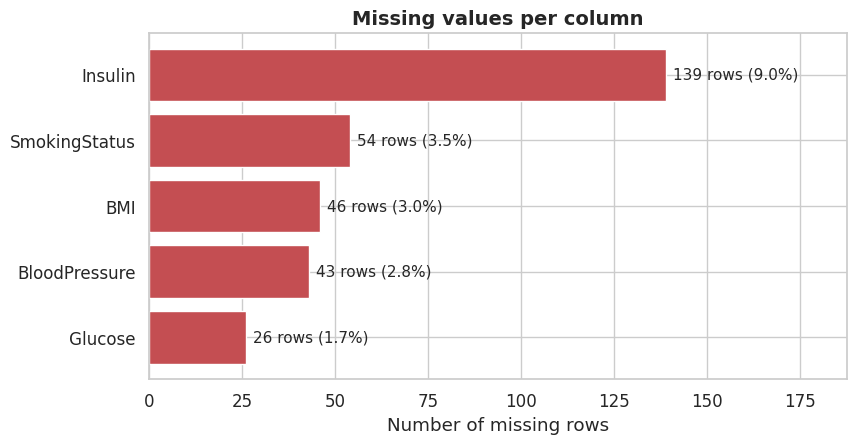

In [17]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values()
missing_percent = missing / len(df) * 100

plt.figure(figsize=(9, 4.5))
bars = plt.barh(missing.index, missing.values, color="#C44E52")

for bar, m, p in zip(bars, missing.values, missing_percent.values):
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
             f"{m} rows ({p:.1f}%)", va="center", fontsize=11)

plt.title("Missing values per column", fontsize=14, fontweight="bold")
plt.xlabel("Number of missing rows")
plt.xlim(0, missing.max() * 1.35)
plt.show()

checking the number of missing values and thier persentge and considiring imputation methods

In [18]:
numerical_cols = ["BMI", "Glucose", "BloodPressure", "Insulin"]

for col in numerical_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"{col}: filled with median = {median_value}")

mode_value = df["SmokingStatus"].mode()[0]
df["SmokingStatus"] = df["SmokingStatus"].fillna(mode_value)
print(f"SmokingStatus: filled with mode = {mode_value}")

BMI: filled with median = 27.7
Glucose: filled with median = 102.0
BloodPressure: filled with median = 75.0
Insulin: filled with median = 101.0
SmokingStatus: filled with mode = Never


In [19]:
print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


In [20]:
print("Rows before:", len(df))
print("Duplicated rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Rows after:", len(df))

Rows before: 1545
Duplicated rows: 45
Rows after: 1500


In [21]:
print("Before:", list(df["Gender"].unique()))

df["Gender"] = df["Gender"].str.strip().str.lower()

df["Gender"] = df["Gender"].replace({
    "m": "male",
    "f": "female",
})

print("After: ", list(df["Gender"].unique()))

Before: ['Male', 'Female', 'M', 'F', 'male', 'female']
After:  ['male', 'female']


In [22]:
df = df.drop(columns=["PatientID"])

In [23]:
df["Gender"] = df["Gender"].map({"female": 0, "male": 1})

df["FamilyHistory"] = df["FamilyHistory"].map({"No": 0, "Yes": 1})

df["ActivityLevel"] = df["ActivityLevel"].map({"Low": 0, "Medium": 1, "High": 2})

df = pd.get_dummies(df, columns=["SmokingStatus"], prefix="Smoking", dtype=int)

df.head()

,Age,Gender,BMI,Glucose,BloodPressure,Insulin,FamilyHistory,ActivityLevel,Diabetes,Smoking_Current,Smoking_Former,Smoking_Never
0,48,1,28.4,86.0,61.0,94.0,0.0,0,0,0,0,1
1,50,1,19.9,106.0,69.0,99.0,NaN,1,1,1,0,0
2,69,0,28.6,153.0,60.0,121.0,0.0,1,1,0,0,1
3,65,0,27.5,105.0,66.0,137.0,0.0,2,0,1,0,0
4,42,0,36.4,123.0,95.0,165.0,0.0,2,0,0,0,1


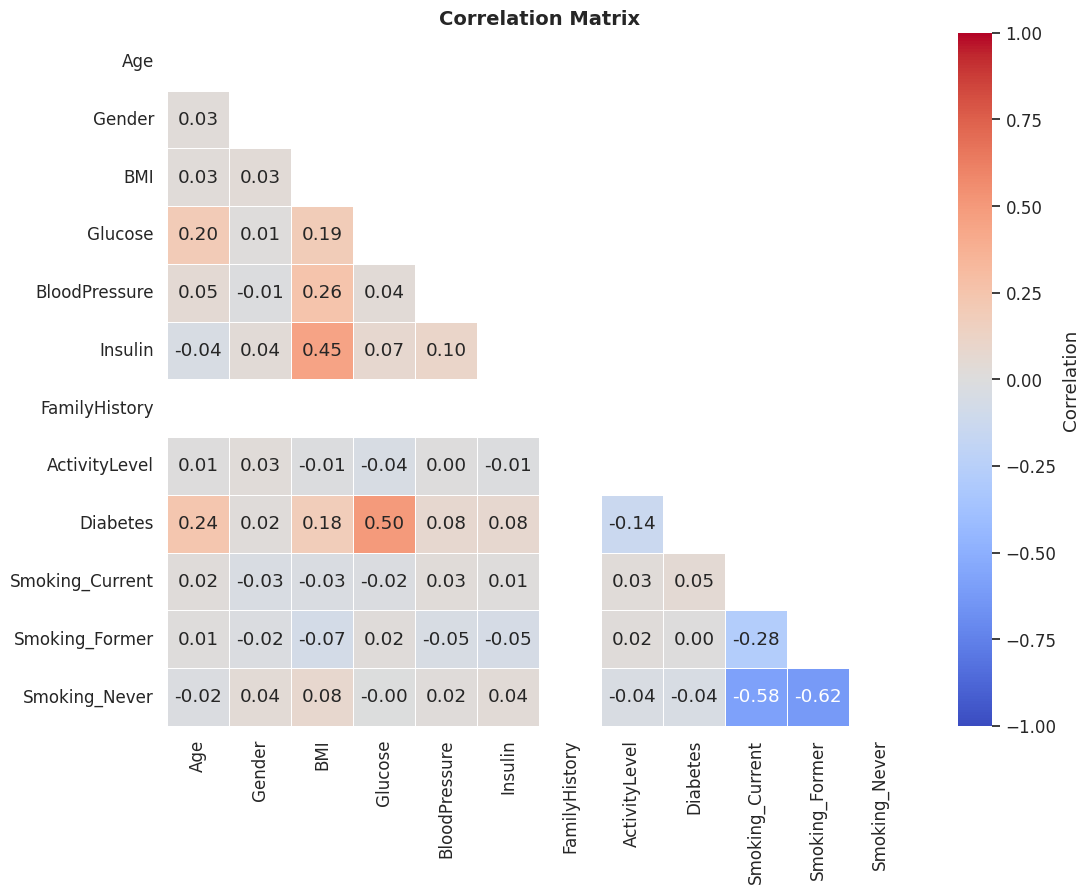

In [24]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.grid(False)
plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.show()

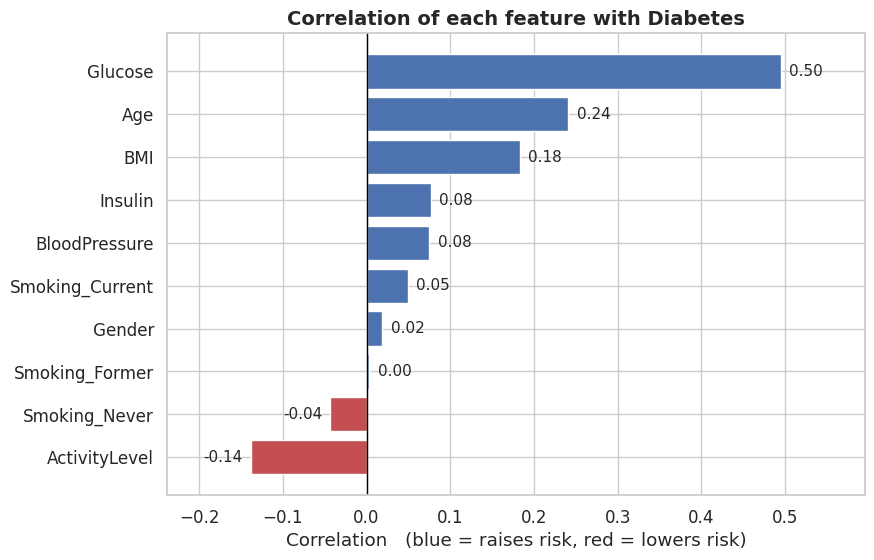

In [25]:
target_corr = corr["Diabetes"].drop("Diabetes").sort_values()
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in target_corr.values]

plt.figure(figsize=(9, 6))
bars = plt.barh(target_corr.index, target_corr.values, color=colors)

for bar, v in zip(bars, target_corr.values):
    offset = 0.01 if v >= 0 else -0.01
    align = "left" if v >= 0 else "right"
    plt.text(v + offset, bar.get_y() + bar.get_height() / 2, f"{v:.2f}",
             va="center", ha=align, fontsize=11)

plt.axvline(0, color="black", linewidth=1)
plt.title("Correlation of each feature with Diabetes", fontsize=14, fontweight="bold")
plt.xlabel("Correlation   (blue = raises risk, red = lowers risk)")
plt.xlim(target_corr.min() - 0.1, target_corr.max() + 0.1)
plt.show()

another or clearer representation of the correlation matrix and the positive and negative relations

In [26]:
X = df.drop(columns=["Diabetes"])#Target Leakage.
y = df["Diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("Train:", X_train.shape, "  Diabetes rate:", round(y_train.mean(), 2))
print("Test: ", X_test.shape, "  Diabetes rate:", round(y_test.mean(), 2))

Train: (1200, 11)   Diabetes rate: 0.27
Test:  (300, 11)   Diabetes rate: 0.27


In [27]:
scale_cols = ["Age", "BMI", "Glucose", "BloodPressure", "Insulin"]

scaler = StandardScaler()
scaler.fit(X_train[scale_cols])                               # learn from Train only

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[scale_cols] = scaler.transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

comparison = pd.DataFrame({
    "Mean before": X_train[scale_cols].mean(),
    "Std before": X_train[scale_cols].std(),
    "Mean after": X_train_scaled[scale_cols].mean(),
    "Std after": X_train_scaled[scale_cols].std(),
}).round(2)
comparison

,Mean before,Std before,Mean after,Std after
Age,50.00,17.12,-0.0,1.0
BMI,28.04,5.84,0.0,1.0
Glucose,101.41,22.42,-0.0,1.0
BloodPressure,74.97,9.02,0.0,1.0
Insulin,101.38,37.57,0.0,1.0


In [28]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)                  # 0 or 1
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]      # probability of diabetes

In [29]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

lgbm_model.fit(X_train_scaled, y_train)

lgbm_pred = lgbm_model.predict(X_test_scaled)
lgbm_prob = lgbm_model.predict_proba(X_test_scaled)[:, 1]

In [30]:
exercise = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_pred,
}).sample(20, random_state=119).reset_index(drop=True)

exercise.index = exercise.index + 1
exercise.index.name = "Patient"
exercise

,Actual,Predicted
Patient,,
1,1,0
2,0,1
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [31]:
def outcome(row):
    if row["Actual"] == 1 and row["Predicted"] == 1:
        return "TP"
    if row["Actual"] == 0 and row["Predicted"] == 0:
        return "TN"
    if row["Actual"] == 0 and row["Predicted"] == 1:
        return "FP"
    return "FN"

exercise["Outcome"] = exercise.apply(outcome, axis=1)
exercise

,Actual,Predicted,Outcome
Patient,,,
1,1,0,FN
2,0,1,FP
3,0,0,TN
4,0,0,TN
5,0,0,TN
6,0,0,TN
7,0,0,TN
8,0,0,TN
9,0,0,TN


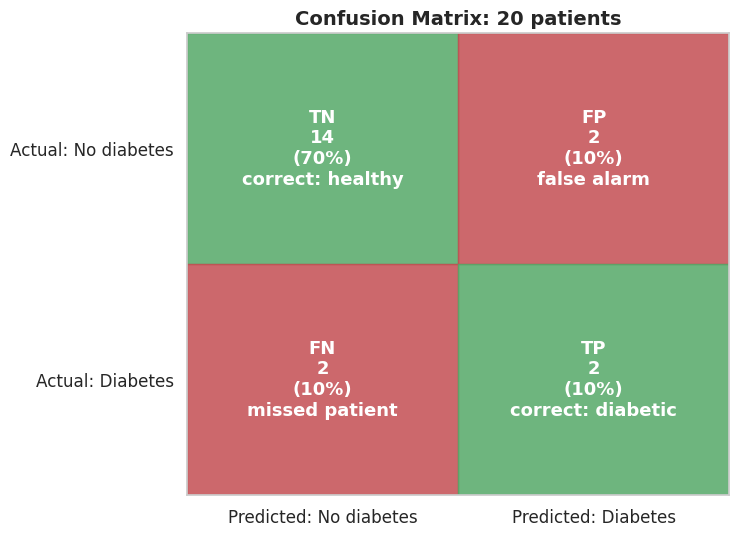

TP = 2   TN = 14   FP = 2   FN = 2   Total = 20

Accuracy  = (TP + TN) / Total        = (2 + 14) / 20       = 0.800
Precision = TP / (TP + FP)           = 2 / (2 + 2)         = 0.500
Recall    = TP / (TP + FN)           = 2 / (2 + 2)         = 0.500
F1 Score  = 2 * P * R / (P + R)      = 2 * 0.500 * 0.500 / (0.500 + 0.500) = 0.500


In [32]:
def plot_confusion_matrix(actual, predicted, title):
    cm = confusion_matrix(actual, predicted)
    names = [["TN", "FP"], ["FN", "TP"]]
    meaning = [["correct: healthy", "false alarm"], ["missed patient", "correct: diabetic"]]
    colors = [["#55A868", "#C44E52"], ["#C44E52", "#55A868"]]
    total = cm.sum()

    fig, ax = plt.subplots(figsize=(7, 6))
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color=colors[i][j], alpha=0.85))
            ax.text(j + 0.5, i + 0.5,
                    f"{names[i][j]}\n{cm[i, j]}\n({cm[i, j] / total:.0%})\n{meaning[i][j]}",
                    ha="center", va="center", fontsize=13, color="white", fontweight="bold")

    ax.set_xlim(0, 2)
    ax.set_ylim(2, 0)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(["Predicted: No diabetes", "Predicted: Diabetes"])
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(["Actual: No diabetes", "Actual: Diabetes"])
    ax.grid(False)
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.show()


def explain_metrics(actual, predicted):
    tn, fp, fn, tp = confusion_matrix(actual, predicted).ravel()
    total = tp + tn + fp + fn

    accuracy = (tp + tn) / total
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall)

    print(f"TP = {tp}   TN = {tn}   FP = {fp}   FN = {fn}   Total = {total}")
    print()
    print(f"Accuracy  = (TP + TN) / Total        = ({tp} + {tn}) / {total}       = {accuracy:.3f}")
    print(f"Precision = TP / (TP + FP)           = {tp} / ({tp} + {fp})         = {precision:.3f}")
    print(f"Recall    = TP / (TP + FN)           = {tp} / ({tp} + {fn})         = {recall:.3f}")
    print(f"F1 Score  = 2 * P * R / (P + R)      = 2 * {precision:.3f} * {recall:.3f} / ({precision:.3f} + {recall:.3f}) = {f1:.3f}")


plot_confusion_matrix(exercise["Actual"], exercise["Predicted"], "Confusion Matrix: 20 patients")
explain_metrics(exercise["Actual"], exercise["Predicted"])

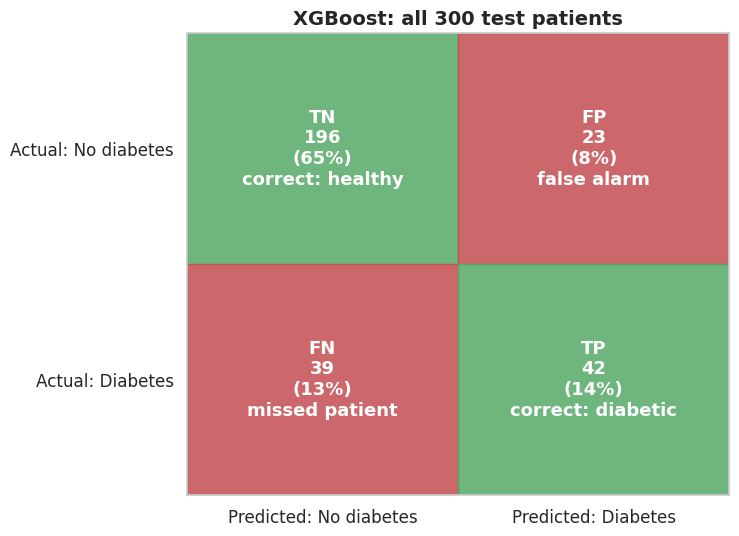

TP = 42   TN = 196   FP = 23   FN = 39   Total = 300

Accuracy  = (TP + TN) / Total        = (42 + 196) / 300       = 0.793
Precision = TP / (TP + FP)           = 42 / (42 + 23)         = 0.646
Recall    = TP / (TP + FN)           = 42 / (42 + 39)         = 0.519
F1 Score  = 2 * P * R / (P + R)      = 2 * 0.646 * 0.519 / (0.646 + 0.519) = 0.575


In [33]:
plot_confusion_matrix(y_test, xgb_pred, f"XGBoost: all {len(y_test)} test patients")
explain_metrics(y_test, xgb_pred)

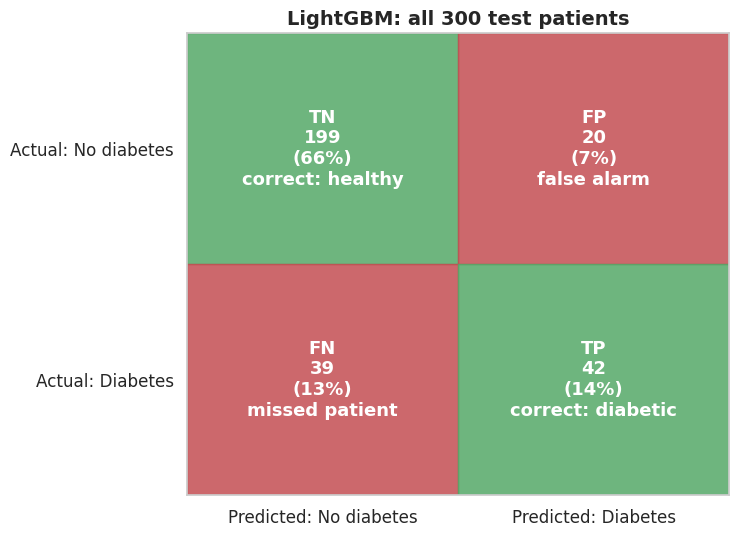

TP = 42   TN = 199   FP = 20   FN = 39   Total = 300

Accuracy  = (TP + TN) / Total        = (42 + 199) / 300       = 0.803
Precision = TP / (TP + FP)           = 42 / (42 + 20)         = 0.677
Recall    = TP / (TP + FN)           = 42 / (42 + 39)         = 0.519
F1 Score  = 2 * P * R / (P + R)      = 2 * 0.677 * 0.519 / (0.677 + 0.519) = 0.587


In [34]:
plot_confusion_matrix(y_test, lgbm_pred, f"LightGBM: all {len(y_test)} test patients")
explain_metrics(y_test, lgbm_pred)

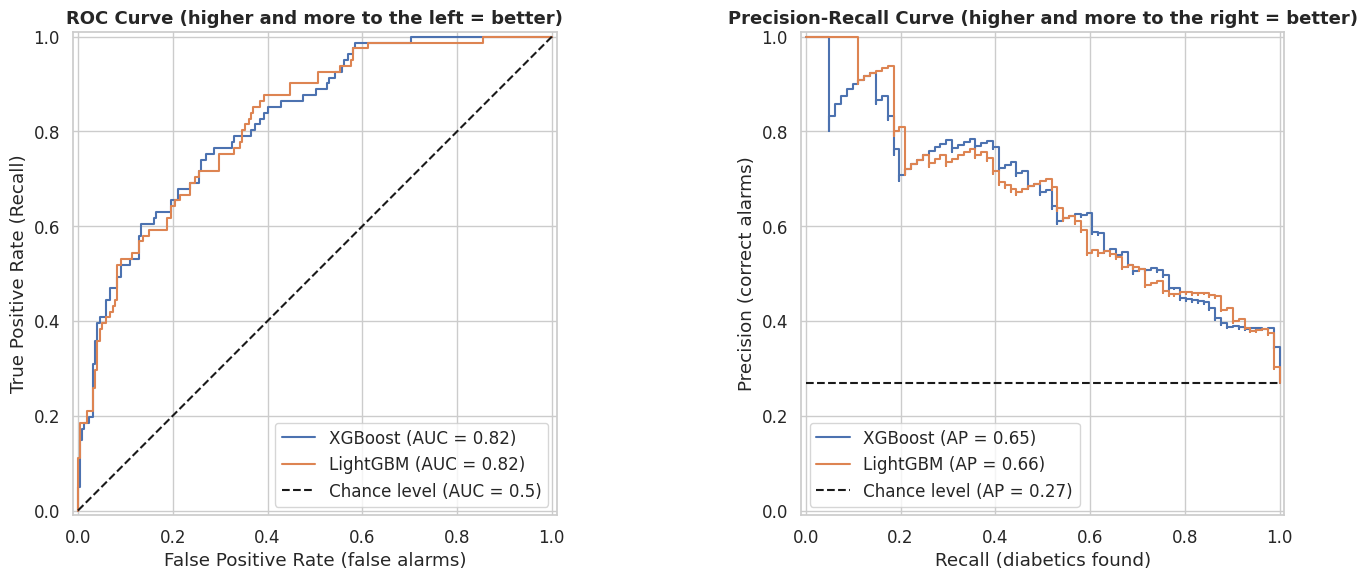

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

RocCurveDisplay.from_predictions(y_test, xgb_prob, name="XGBoost", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, lgbm_prob, name="LightGBM", ax=axes[0], plot_chance_level=True)
axes[0].set_title("ROC Curve (higher and more to the left = better)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate (false alarms)")
axes[0].set_ylabel("True Positive Rate (Recall)")

PrecisionRecallDisplay.from_predictions(y_test, xgb_prob, name="XGBoost", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, lgbm_prob, name="LightGBM", ax=axes[1], plot_chance_level=True)
axes[1].set_title("Precision-Recall Curve (higher and more to the right = better)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recall (diabetics found)")
axes[1].set_ylabel("Precision (correct alarms)")

plt.tight_layout()
plt.show()

In [36]:
def all_metrics(actual, predicted, probability):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted),
        "Recall": recall_score(actual, predicted),
        "F1 Score": f1_score(actual, predicted),
        "ROC-AUC": roc_auc_score(actual, probability),
        "PR-AUC": average_precision_score(actual, probability),
    }

results = pd.DataFrame({
    "XGBoost": all_metrics(y_test, xgb_pred, xgb_prob),
    "LightGBM": all_metrics(y_test, lgbm_pred, lgbm_prob),
}).round(3)

results

,XGBoost,LightGBM
Accuracy,0.793,0.803
Precision,0.646,0.677
Recall,0.519,0.519
F1 Score,0.575,0.587
ROC-AUC,0.823,0.821
PR-AUC,0.652,0.657


In [46]:
explainer = shap.TreeExplainer(
    xgb_model,
    feature_perturbation="tree_path_dependent",
    model_output="raw"
)

shap_values = explainer(X_test_scaled)

# show original values instead of scaled values in the plots
shap_values.data = X_test.values
print("Average risk (starting point):", round(shap_values.base_values[0], 2))

Average risk (starting point): -1.0


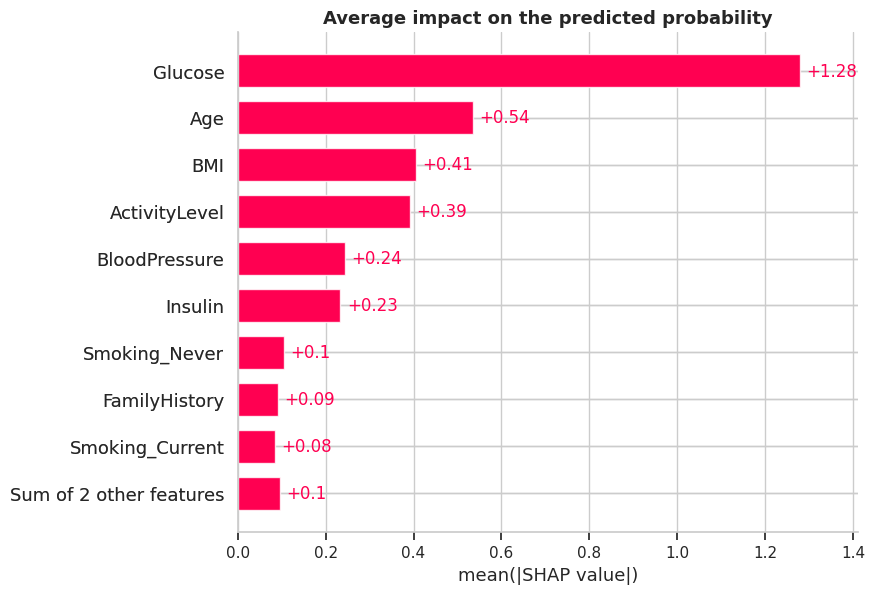

In [47]:
shap.plots.bar(shap_values, show=False)
plt.title("Average impact on the predicted probability", fontsize=13, fontweight="bold")
plt.show()

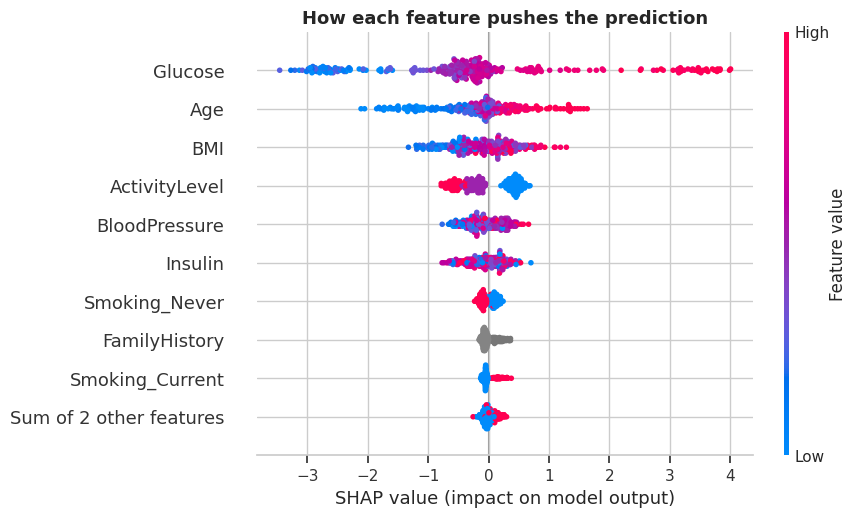

In [49]:
shap.plots.beeswarm(shap_values, show=False)
plt.title("How each feature pushes the prediction", fontsize=13, fontweight="bold")
plt.show()

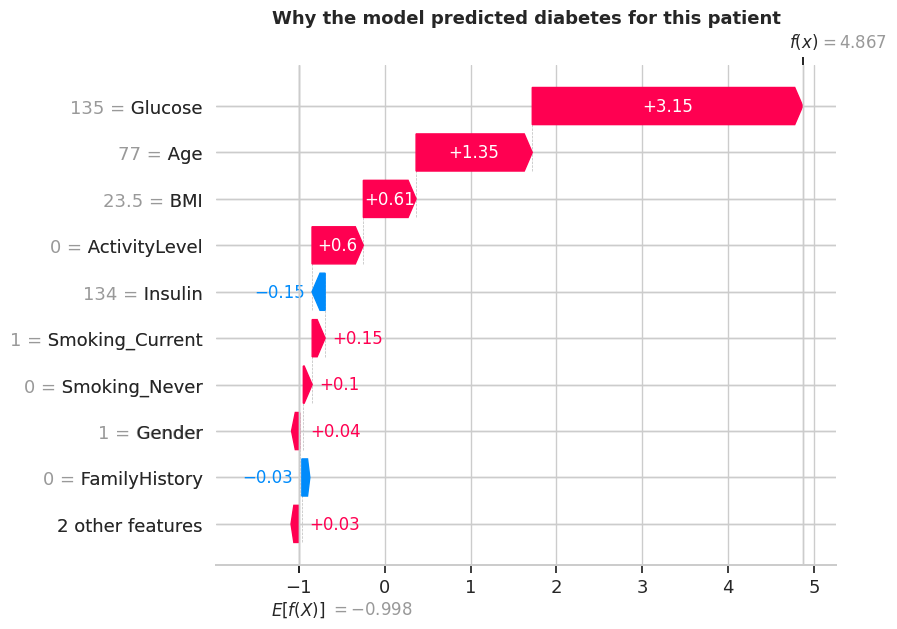

In [50]:
patient = int(np.argmax(xgb_prob))            # the highest-risk patient in the test set

shap.plots.waterfall(shap_values[patient], show=False)
plt.title("Why the model predicted diabetes for this patient", fontsize=13, fontweight="bold")
plt.show()